In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
data = pd.read_csv("/content/health_fitness_dataset.csv")
data.head(5)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [6]:
data.shape

(175832, 22)

In [7]:
print("Dataset Head:")
print(data.head())
print("\nDataset Info:")
print(data.info())
print("\nSummary Statistics:")
print(data.describe())

Dataset Head:
   participant_id        date  age gender  height_cm  weight_kg  \
0               1  2024-01-01   56      F      165.3       53.7   
1               1  2024-01-04   56      F      165.3       53.9   
2               1  2024-01-05   56      F      165.3       54.2   
3               1  2024-01-07   56      F      165.3       54.4   
4               1  2024-01-09   56      F      165.3       54.7   

     activity_type  duration_minutes intensity  calories_burned  ...  \
0          Dancing                41       Low              3.3  ...   
1         Swimming                28       Low              2.9  ...   
2         Swimming                21    Medium              2.6  ...   
3  Weight Training                99    Medium             10.7  ...   
4         Swimming               100    Medium             12.7  ...   

   stress_level  daily_steps  hydration_level   bmi  resting_heart_rate  \
0             3         7128              1.5  19.6                69.5   


In [8]:
data.isnull().sum()

,0
participant_id,0
date,0
age,0
gender,0
height_cm,0
weight_kg,0
activity_type,0
duration_minutes,0
intensity,0
calories_burned,0


In [9]:
data = data.drop('health_condition', axis=1)
data.isnull().sum()

,0
participant_id,0
date,0
age,0
gender,0
height_cm,0
weight_kg,0
activity_type,0
duration_minutes,0
intensity,0
calories_burned,0


In [10]:
target_column = 'fitness_level'
data = data.dropna(subset=[target_column])


In [11]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
quantitative_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nQuantitative Features:")
print(quantitative_features)

Categorical Features:
['date', 'gender', 'activity_type', 'intensity', 'smoking_status']

Quantitative Features:
['participant_id', 'age', 'height_cm', 'weight_kg', 'duration_minutes', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fitness_level']


In [12]:
categorical_columns = data.select_dtypes(include=['object']).columns
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column].astype(str))
    label_encoders[column] = le

In [13]:
data.dtypes

,0
participant_id,int64
date,int64
age,int64
gender,int64
height_cm,float64
weight_kg,float64
activity_type,int64
duration_minutes,int64
intensity,int64
calories_burned,float64


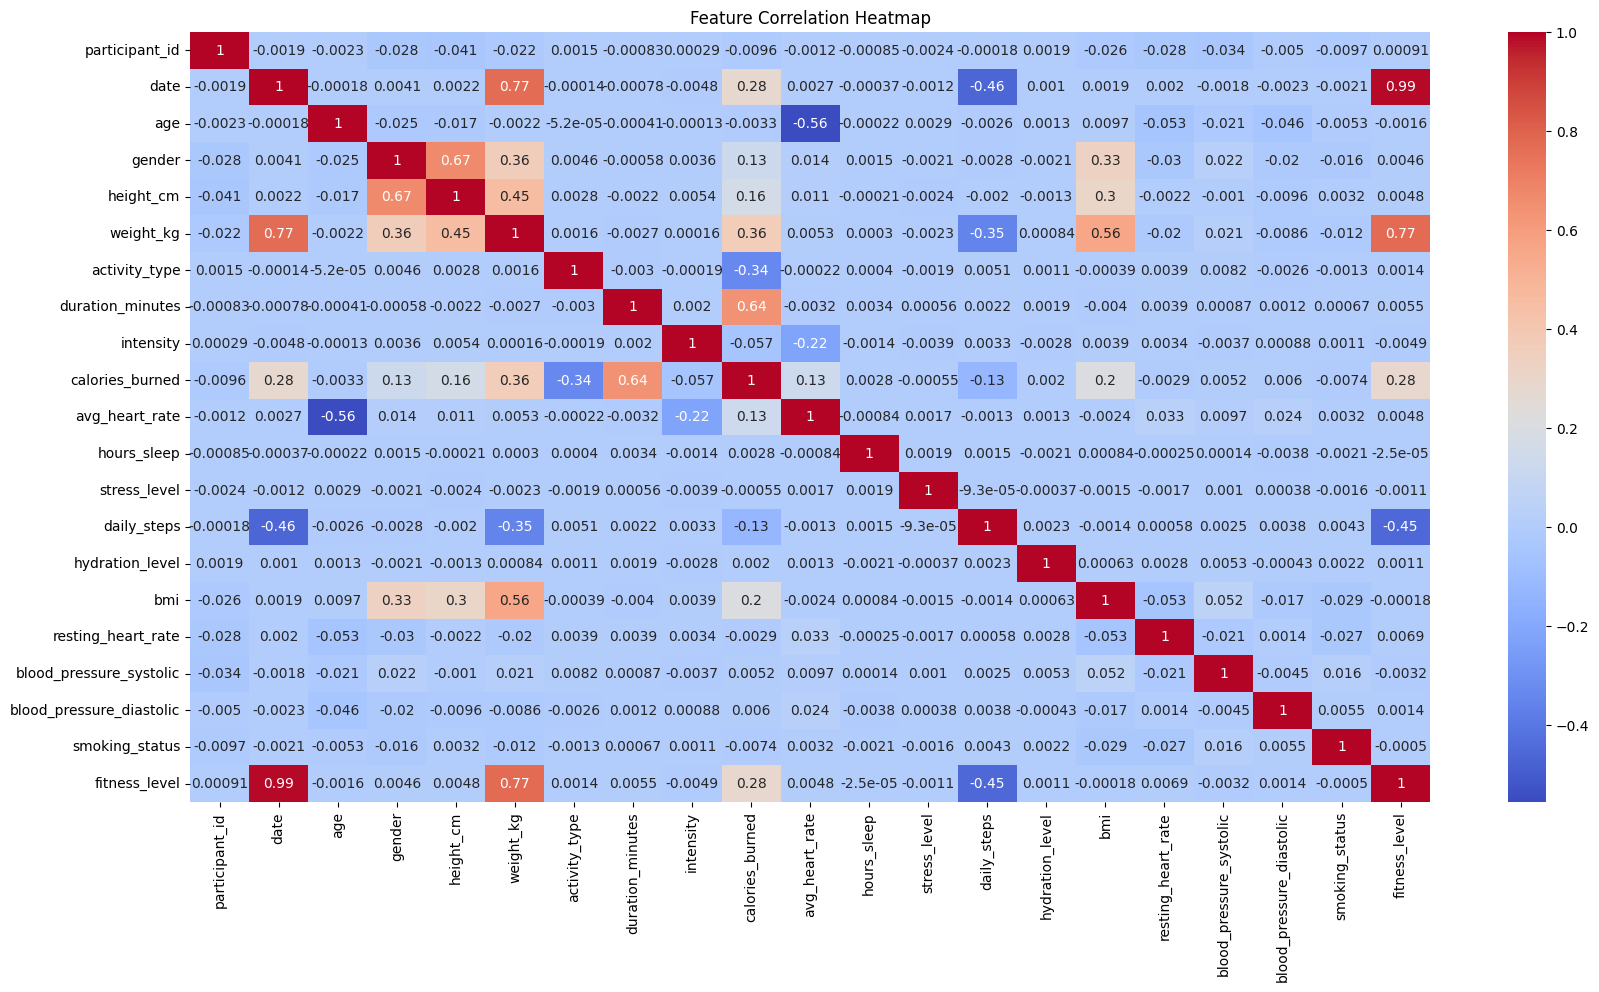

In [14]:
data_corr = data.corr()
plt.figure(figsize = (20,10))
sns.heatmap(data_corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

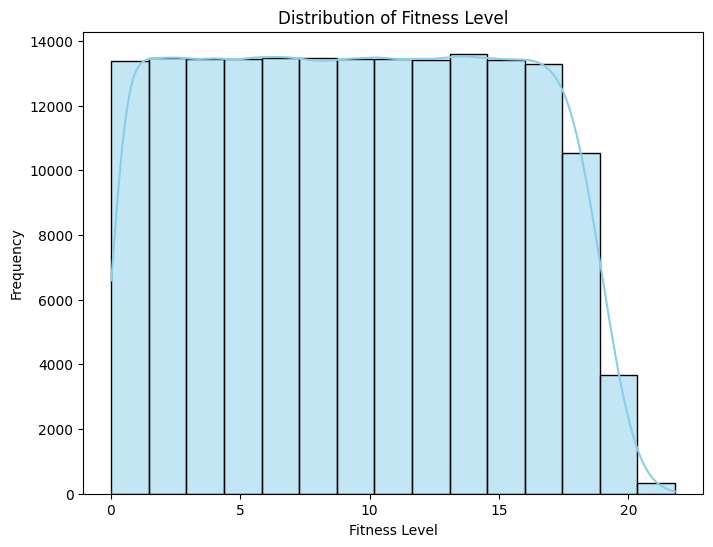

The dataset is relatively imbalanced.


In [15]:
plt.figure(figsize=(8, 6))
sns.histplot(data['fitness_level'], kde=True, color='skyblue', bins=15)
plt.title('Distribution of Fitness Level')
plt.xlabel('Fitness Level')
plt.ylabel('Frequency')
plt.show()

std_dev = data['fitness_level'].std()
mean = data['fitness_level'].mean()

if abs(std_dev / mean) < 0.1:
    print("The dataset is relatively balanced.")
else:
    print("The dataset is relatively imbalanced.")


In [16]:
unnecessary_columns = ['participant_id', 'date']
X = data.drop(columns=[target_column] + unnecessary_columns)
y = data[target_column]

print(f"Features used for training:\n{X.columns.tolist()}")


Features used for training:
['age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status']


Feature **Scaling**

In [17]:
features= data.drop(columns=[target_column] + unnecessary_columns)
y = data[target_column]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_scaled = pd.DataFrame(features_scaled, columns=features.columns)

print("Scaled Features (first 2 rows):")
print(features_scaled.head(2))

print("Target Values (first 2 rows):")
print(y.head(2))

Scaled Features (first 2 rows):
        age    gender  height_cm  weight_kg  activity_type  duration_minutes  \
0  1.072045 -0.998924  -0.371278  -1.858105      -0.873564         -0.995842   
1  1.072045 -0.998924  -0.371278  -1.849125       0.169277         -1.441589   

   intensity  calories_burned  avg_heart_rate  hours_sleep  stress_level  \
0  -0.388159        -1.210966       -1.600561    -0.460112     -0.814153   
1  -0.388159        -1.250995       -1.657160     1.082315      0.630294   

   daily_steps  hydration_level       bmi  resting_heart_rate  \
0    -0.729939        -1.727700 -0.899802           -0.117861   
1    -0.341849        -1.209551 -0.899802           -0.117861   

   blood_pressure_systolic  blood_pressure_diastolic  smoking_status  
0                -0.976561                 -0.942741        0.760527  
1                -0.976561                 -0.942741        0.760527  
Target Values (first 2 rows):
0    0.04
1    0.07
Name: fitness_level, dtype: float64


In [18]:
for col in data.columns.to_list():
  col_var=np.var(data[col])
  print(f"{col}:{round(col_var,2)}")

participant_id:48792.08
date:10575.48
age:175.11
gender:0.28
height_cm:81.5
weight_kg:495.99
activity_type:8.28
duration_minutes:850.57
intensity:0.61
calories_burned:99.85
avg_heart_rate:312.16
hours_sleep:0.95
stress_level:7.67
daily_steps:4217473.63
hydration_level:0.34
bmi:12.45
resting_heart_rate:25.19
blood_pressure_systolic:97.46
blood_pressure_diastolic:62.68
smoking_status:0.57
fitness_level:30.42


Split the dataset

In [19]:
data[target_column].value_counts()

,count
fitness_level,
13.05,121
14.53,118
1.01,118
4.10,118
0.12,118
...,...
21.38,1
21.50,1
21.65,1


In [20]:
X = data.drop(columns=[target_column]+ unnecessary_columns)
y = data[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
data.head(2)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level
0,1,0,56,0,165.3,53.7,2,41,1,3.3,...,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,2,0.04
1,1,3,56,0,165.3,53.9,5,28,1,2.9,...,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,2,0.07


**Model evaluation

In [21]:
#Decision tree
model_dt = DecisionTreeRegressor()
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))


Decision Tree MSE: 0.11384762843601895


In [22]:
#Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))


Linear Regression MSE: 0.25094963242576185


In [23]:
#RF
model_rfr = RandomForestRegressor()
model_rfr.fit(X_train, y_train)
y_pred_rfr = model_rfr.predict(X_test)
print("Random Forset Regression MSE:", mean_squared_error(y_test, y_pred_rfr))


Random Forset Regression MSE: 0.025849743481895764


In [24]:
#MLP
model_mlp= MLPRegressor()
model_mlp.fit(X_train, y_train)
y_pred_mlp = model_mlp.predict(X_test)
print("MLP Regression MSE:", mean_squared_error(y_test, y_pred_mlp))


MLP Regression MSE: 2.382083040867939


In [25]:
print("Model: Decision Tree | MSE:", mean_squared_error(y_test, y_pred_dt), "| R2 Score:", r2_score(y_test, y_pred_dt))
print("Model: Linear Regression | MSE:", mean_squared_error(y_test, y_pred_lr), "| R2 Score:", r2_score(y_test, y_pred_lr))
print("Model: Random Forest Regressor | MSE:", mean_squared_error(y_test, y_pred_rfr), "| R2 Score:", r2_score(y_test, y_pred_rfr))
print("Model: MLP Regressor | MSE:", mean_squared_error(y_test, y_pred_mlp), "| R2 Score:", r2_score(y_test, y_pred_mlp))



Model: Decision Tree | MSE: 0.11384762843601895 | R2 Score: 0.9962491972848401
Model: Linear Regression | MSE: 0.25094963242576185 | R2 Score: 0.9917322602534501
Model: Random Forest Regressor | MSE: 0.025849743481895764 | R2 Score: 0.9991483591764709
Model: MLP Regressor | MSE: 2.382083040867939 | R2 Score: 0.9215203367855394


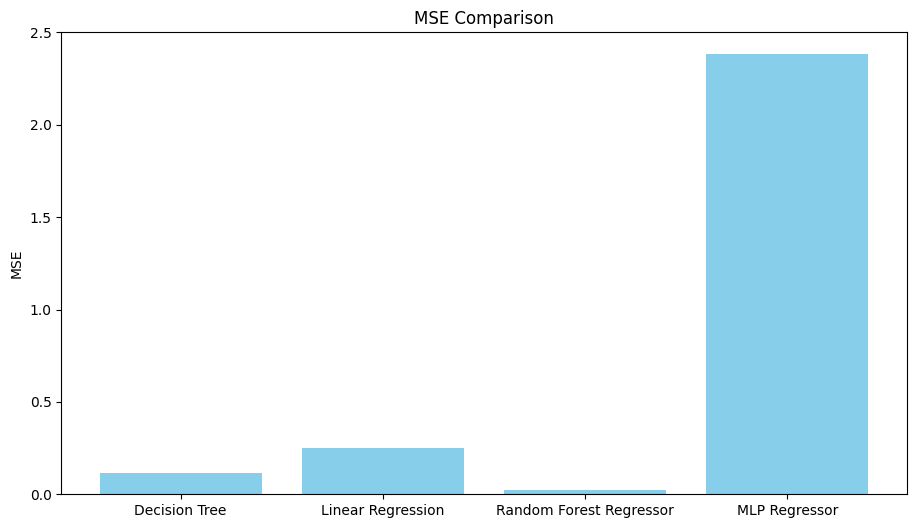

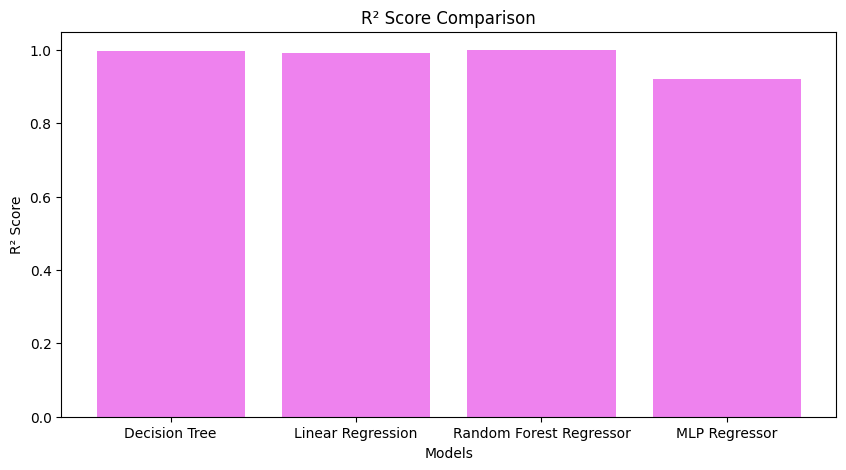

In [26]:
results = {
    "Decision Tree": [mean_squared_error(y_test, y_pred_dt), r2_score(y_test, y_pred_dt)],
    "Linear Regression": [mean_squared_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)],
    "Random Forest Regressor": [mean_squared_error(y_test, y_pred_rfr), r2_score(y_test, y_pred_rfr)],
    "MLP Regressor": [mean_squared_error(y_test, y_pred_mlp), r2_score(y_test, y_pred_mlp)],
}

models = list(results.keys())
mse_scores = [res[0] for res in results.values()]
r2_scores = [res[1] for res in results.values()]

plt.figure(figsize=(24,6))
plt.subplot(1, 2, 1)
plt.bar(models, mse_scores, color='skyblue')
plt.title("MSE Comparison")
plt.ylabel("MSE")

plt.figure(figsize=(10, 5))
plt.bar(models, r2_scores, color='violet')
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Models")
plt.show()



Decision Tree: Precision = 0.83, Recall = 0.83, F1 Score = 0.83, Accuracy = 0.83
Linear Regression: Precision = 0.90, Recall = 0.90, F1 Score = 0.90, Accuracy = 0.90
Random Forest Regressor: Precision = 0.95, Recall = 0.95, F1 Score = 0.95, Accuracy = 0.95
MLP Regressor: Precision = 0.46, Recall = 0.46, F1 Score = 0.46, Accuracy = 0.46


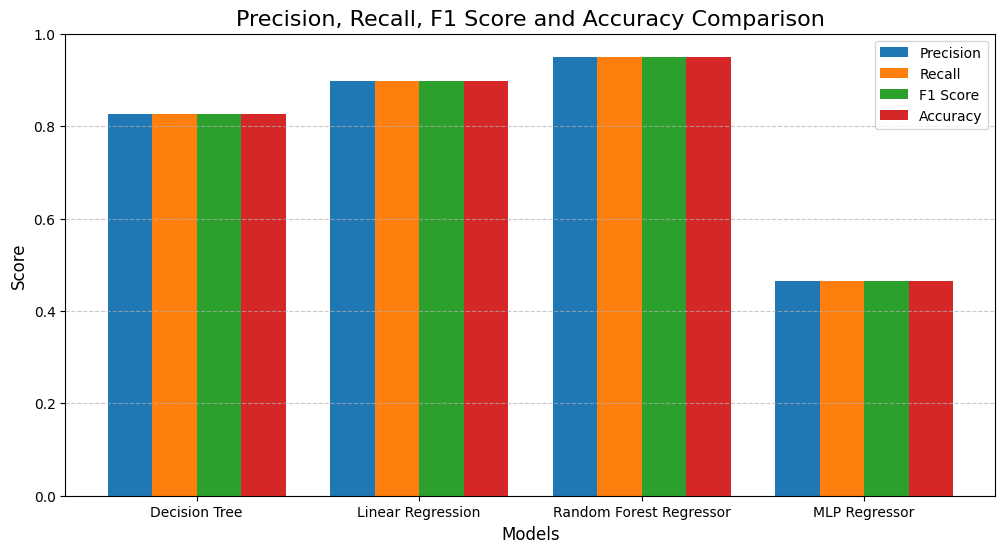

In [29]:
def regression_metrics(y_true, y_pred, tolerance=0.1):
    margin = tolerance * y_true
    correct_predictions = (abs(y_true - y_pred) <= margin)

    accuracy = correct_predictions.mean()

    precision = accuracy
    recall = accuracy

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1, accuracy


precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores = []

for y_pred in [y_pred_lr, y_pred_dt, y_pred_rfr, y_pred_mlp]:
    precision, recall, f1, accuracy = regression_metrics(y_test, y_pred, tolerance=0.1)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    accuracy_scores.append(accuracy)


for i, model in enumerate(models):
    print(f"{model}: Precision = {precision_scores[i]:.2f}, Recall = {recall_scores[i]:.2f}, F1 Score = {f1_scores[i]:.2f}, Accuracy = {accuracy_scores[i]:.2f}")


bar_width = 0.2
positions = np.arange(len(models))

plt.figure(figsize=(12,6))

plt.bar(positions - 1.5*bar_width, precision_scores, width=bar_width, label='Precision')
plt.bar(positions - 0.5*bar_width, recall_scores, width=bar_width, label='Recall')
plt.bar(positions + 0.5*bar_width, f1_scores, width=bar_width, label='F1 Score')
plt.bar(positions + 1.5*bar_width, accuracy_scores, width=bar_width, label='Accuracy')

plt.title("Precision, Recall, F1 Score and Accuracy Comparison", fontsize=16)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)

plt.xticks(positions, models, fontsize=10)
plt.ylim(0,1)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Evaluation for Decision Tree:
Confusion Matrix:
 [[35914     0   310     0]
 [    0  7998   258     2]
 [  292   274  7701     0]
 [    0     1     0     0]]
Classification Report:
               precision    recall  f1-score   support

        High       0.99      0.99      0.99     36224
         Low       0.97      0.97      0.97      8258
      Medium       0.93      0.93      0.93      8267
         nan       0.00      0.00      0.00         1

    accuracy                           0.98     52750
   macro avg       0.72      0.72      0.72     52750
weighted avg       0.98      0.98      0.98     52750



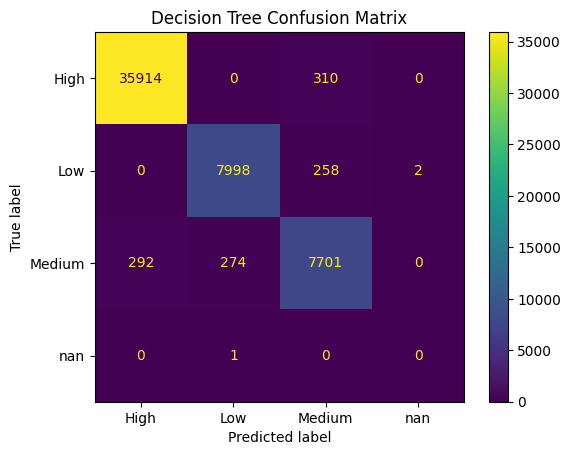

Evaluation for Linear Regression:
Confusion Matrix:
 [[35711     0   513     0]
 [    0  7491   503   264]
 [  565   380  7322     0]
 [    0     1     0     0]]
Classification Report:
               precision    recall  f1-score   support

        High       0.98      0.99      0.99     36224
         Low       0.95      0.91      0.93      8258
      Medium       0.88      0.89      0.88      8267
         nan       0.00      0.00      0.00         1

    accuracy                           0.96     52750
   macro avg       0.70      0.69      0.70     52750
weighted avg       0.96      0.96      0.96     52750



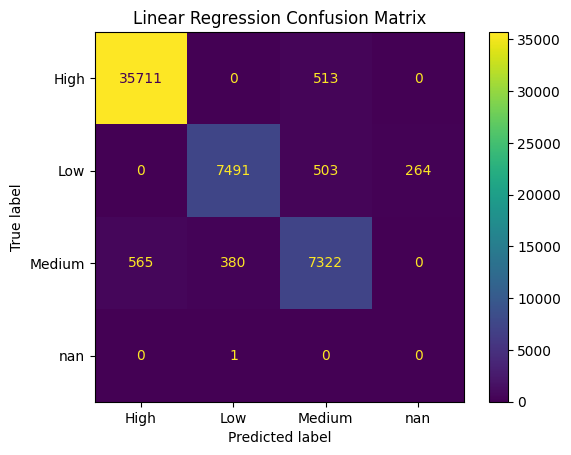

Evaluation for Random Forest:
Confusion Matrix:
 [[36056     0   168     0]
 [    0  8099   159     0]
 [  189   129  7949     0]
 [    0     1     0     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

        High       0.99      1.00      1.00     36224
         Low       0.98      0.98      0.98      8258
      Medium       0.96      0.96      0.96      8267
         nan       0.00      0.00      0.00         1

    accuracy                           0.99     52750
   macro avg       0.73      0.73      0.73     52750
weighted avg       0.99      0.99      0.99     52750



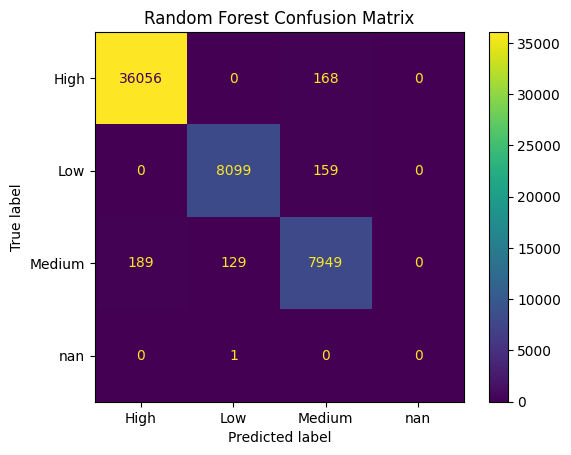

Evaluation for Multi Layer Perceptron:
Confusion Matrix:
 [[35916     0   249    59]
 [  170  4428  3471   189]
 [ 3522   179  4566     0]
 [    0     1     0     0]]
Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.99      0.95     36224
         Low       0.96      0.54      0.69      8258
      Medium       0.55      0.55      0.55      8267
         nan       0.00      0.00      0.00         1

    accuracy                           0.85     52750
   macro avg       0.60      0.52      0.55     52750
weighted avg       0.86      0.85      0.84     52750



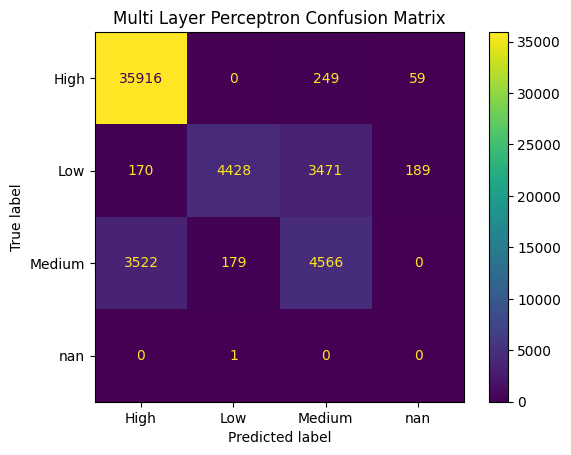

In [30]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"Evaluation for {model_name}:")
    conf_matrix = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    report = classification_report(y_true, y_pred)
    print("Classification Report:\n", report)

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

bins = [data['fitness_level'].min(), 3, 6, data['fitness_level'].max()]
labels = ['Low', 'Medium', 'High']

y_test_discretized = pd.cut(y_test, bins=bins, labels=labels).astype(str)

y_pred_dt_discretized = pd.cut(y_pred_dt, bins=bins, labels=labels).astype(str)
evaluate_model(y_test_discretized, y_pred_dt_discretized, "Decision Tree")

y_pred_lr_discretized = pd.cut(y_pred_lr, bins=bins, labels=labels).astype(str)
evaluate_model(y_test_discretized, y_pred_lr_discretized, "Linear Regression")

y_pred_rfr_discretized = pd.cut(y_pred_rfr, bins=bins, labels=labels).astype(str)
evaluate_model(y_test_discretized, y_pred_rfr_discretized, "Random Forest")

y_pred_mlp_discretized = pd.cut(y_pred_mlp, bins=bins, labels=labels).astype(str)
evaluate_model(y_test_discretized, y_pred_mlp_discretized, "Multi Layer Perceptron")

